# Physics Loss Investigation Adaptive Physics - Two Stages Approach.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import pvlib
from pvlib import location, pvsystem, modelchain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS
import re


In [2]:
# -----------------------------------------------------------------------------
# 1. Data Loading & Generation (Same as Mamba)
# -----------------------------------------------------------------------------


import pandas as pd
import re
import numpy as np
from pvlib import location, pvsystem, modelchain
from pvlib.modelchain import ModelChain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS

def get_station_metadata(station_num, df):
    """
    Retrieves and parses metadata for a specific station from the DataFrame.
    
    Args:
        station_num (int or str): The station number (e.g., 5 or '05').
        df (pd.DataFrame): The source dataframe containing station metadata.
        
    Returns:
        dict: A clean dictionary with numerical values ready for simulation.
    """
    
    # 1. Format the station ID
    station_id_str = f"station{str(station_num).zfill(2)}"
    
    # 2. Filter the dataframe
    station_row = df[df['Station_ID'] == station_id_str]
    
    if station_row.empty:
        raise ValueError(f"Station ID {station_id_str} not found in DataFrame.")
    
    # Get the single row as a Series
    row = station_row.iloc[0]

    # --- Helper 1: Parse "Key:Value" blocks (lines separated by \n) ---
    def parse_kv_string(text_block):
        data = {}
        if isinstance(text_block, str):
            for item in text_block.split('\n'):
                if ':' in item:
                    k, v = item.split(':', 1)
                    data[k.strip()] = v.strip()
        return data

    # --- Helper 2: Extract numeric values safely (e.g., "250 Wp" -> 250.0) ---
    def extract_num(val, default=0.0):
        if pd.isna(val): return default
        match = re.search(r"[-+]?\d*\.\d+|\d+", str(val))
        return float(match.group()) if match else default

    # 3. Parse complex text columns into dictionaries
    module_items = parse_kv_string(row.get('Module', ''))
    inverter_items = parse_kv_string(row.get('Inverters', ''))
    layout_items = parse_kv_string(row.get('Layout', ''))

    # 4. Build the final clean dictionary
    # We use extract_num to ensure we pass numbers (floats/ints) to the model, not strings.
    metadata = {
        # --- Identity & Location ---
        'Station_ID': station_id_str,
        'Longitude': float(row['Longitude']),
        'Latitude': float(row['Latitude']),
        'Array_Tilt': row['Array_Tilt'], # Kept as string (e.g., "South 30") for parsing in main model
        
        # --- System Capacity & Dimensions ---
        'Capacity': float(row['Capacity']),          # Total Station Capacity (kW)
        'Panel_Size': float(row.get('Panel_Size', 1.62)), # Panel Area in m^2
        'Total_Panel_Number': int(row.get('Panel_Number', 0)),
        'PV_Technology': row['PV_Technology'],

        # --- Extracted Module Specs (Cleaned to Float) ---
        'Module_Pmax': extract_num(module_items.get('Pmax'), default=250),
        'Module_Vmpp': extract_num(module_items.get('Vmpp'), default=30),
        'Module_Impp': extract_num(module_items.get('Impp'), default=8),
        
        # --- Extracted Inverter Specs (Cleaned to Float) ---
        'Inverter_Rated_Power': extract_num(inverter_items.get('Rated power'), default=500),
        'Inverter_Max_DC_Voltage': extract_num(inverter_items.get('Max. DC voltage'), default=1000),
        
        # --- Extracted Layout Specs (Cleaned to Int) ---
        # Note: Layout strings can look like "modules per string:20"
        'Modules_per_String': int(extract_num(layout_items.get('modules per string'), default=20)),
        'Strings_per_Inverter': int(extract_num(layout_items.get('strings per inverter'), default=100)),
    }
    
    return metadata


def calculate_clearsky_indices(metadata, df):
    """
    Calculates both Irradiance (K_CS) and Power (K_PV) Clear Sky Indices.
    
    Args:
        metadata (dict): Parsed station metadata.
        df (pd.DataFrame): Time-series data with 'lmd_totalirrad' and 'power' columns.
                           'power' should be in MW (or kW, logic adapts).
                           'lmd_totalirrad' should be in W/m^2.
    
    Returns:
        pd.DataFrame: Original df with added columns 'GHI_clr', 'K_CS', 'P_CLR', 'K_PV'.
    """
    
    print(f"--- Processing {metadata.get('Station_ID', 'Unknown')} ---")
    
    # ---------------------------------------------------------
    # 1. SETUP LOCATION & TIME
    # ---------------------------------------------------------
    # The paper explicitly states timestamps are in Coordinated Universal Time (UTC).
    # Setting tz='UTC' ensures pvlib aligns Solar Noon correctly (approx 04:00 UTC for China).
    lat = metadata['Latitude']
    lon = metadata['Longitude']
    
    site = location.Location(lat, lon, tz='UTC')
    
    # Ensure index is Datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df['date_time'] = pd.to_datetime(df['date_time'])
        df.set_index('date_time', inplace=True)

    # ---------------------------------------------------------
    # 2. CALCULATE CLEAR SKY IRRADIANCE (GHI_clr)
    # ---------------------------------------------------------
    print("Calculating Clear Sky Irradiance (Ineichen model)...")
    
    # Calculate theoretical GHI (returns W/m^2)
    cs = site.get_clearsky(df.index, model='ineichen')
    df['GHI_clr'] = cs['ghi']

    # --- Index 1: Irradiance Clear Sky Index (K_CS) ---
    # Formula: K_CS = Measured GHI / Clear Sky GHI
    
    if 'lmd_totalirrad' in df.columns:
        # Standardize Measured Units: 
        # lmd_totalirrad is W/m^2.
        meas_ghi = df['lmd_totalirrad']
        

        # Calculate Index (Filter: Only when model expects sun > 10 W/m^2)
        # Naive filter to avoid night time noise
        df['K_CS_day'] = np.where(
            df['GHI_clr'] > 10, 
            meas_ghi / df['GHI_clr'], 
            0.0
        )
        df['K_CS_dayNight'] = meas_ghi / df['GHI_clr']

        df['K_CS'] = df['K_CS_day']
        
        # Clip outliers (cloud edge effects can cause > 1.0)
        df['K_CS'] = df['K_CS'].clip(lower=0.0, upper=1.25)
    else:
        print("Warning: 'lmd_totalirrad' column missing. K_CS not calculated.")

    # ---------------------------------------------------------
    # 3. SETUP PV SYSTEM MODEL (For P_CLR)
    # ---------------------------------------------------------
    # Extract Tilt safely from string 
    try:
        tilt_str = str(metadata.get('Array_Tilt'))
        tilt_match = re.search(r"[\d.]+", tilt_str)
        tilt = float(tilt_match.group()) if tilt_match else 33.0
    except Exception as e:
        print(f"Error extracting tilt: {e} .... Assuming 33 degrees")
        tilt = 33.0
    
    # Default Azimuth: 180 (South) for Northern Hemisphere
    azimuth = 180 

    # Define Module Parameters (Generic Poly-Si based on metadata)
    # Hard coded Module for specific station 07
    module_params = pvsystem.retrieve_sam('CECMod')['Yingli_Energy__China__YL250P_29b']
    # Module Parameters can be retreived from pvsystem.retrieve_sam by defining the module name and for now for simplicity we use hardcoded one.
    # module_params = {
    #     'pdc0': metadata['Module_Pmax'],   # STC Power (Watts)
    #     'gamma_pdc': -0.004,               # Temp coeff
    #     'b': 0.05, 'a': -3.56              # Sandia model defaults
    # }
    
    # Define Inverter Parameters (One Block)
    # Block Size = Modules per string * Strings per inverter * Module Power
    block_dc_watts = (metadata['Modules_per_String'] * metadata['Strings_per_Inverter'] * metadata['Module_Pmax'])
    

    # The same with Inverter infoirmation i used hardcoded info for station 07    
    # inv_params = pvsystem.retrieve_sam("cecinverter")

    ivt_para = pvsystem.retrieve_sam('cecinverter')['Advanced_Energy_Industries__Solaron_500kW__3159500_XXXX___480V_']
    ivt_para["Pdco"], ivt_para['Vdco'], ivt_para["Vdcmax"], ivt_para['Idcmax'], = 567000, 315, 1000, 1134
    ivt_para["Mppt_low"], ivt_para['Mppt_high'] = 460, 950
    inverter_parameters = ivt_para
    
    # Temperature Model (Open Rack)
    temp_model = TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']
    
    system = pvsystem.PVSystem(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        module_parameters=module_params,
        inverter_parameters=inverter_parameters,
        temperature_model_parameters=temp_model,
        modules_per_string=metadata['Modules_per_String'],
        strings_per_inverter=metadata['Strings_per_Inverter']
        # modules_per_string=20, strings_per_inverter=100 # Must be retreived from metadata, but for now hardcoded
    )

    # ---------------------------------------------------------
    # 4. RUN MODEL CHAIN FOR POWER
    # ---------------------------------------------------------
    print("Running PV Power Simulation...")

    mc = ModelChain(system, site, transposition_model='perez',
                        solar_position_method='nrel_numpy',
                        aoi_model='physical', spectral_model='no_loss')

    # mc = modelchain.ModelChain(
    #     system, 
    #     site, 
    #     aoi_model='physical', 
    #     spectral_model='no_loss', 
    #     ac_model='pvwatts'
    # )

    # Run using the Clear Sky weather data
    mc.run_model(cs)

    # ---------------------------------------------------------
    # 5. SCALE & CALCULATE POWER INDEX (K_PV)
    # ---------------------------------------------------------
    # The simulation (mc.results.ac) is for ONE Block. Scale to full station.
    
    station_total_capacity_watts = metadata['Capacity'] * 1000  # kW -> Watts [cite: 109]
    scaling_factor = station_total_capacity_watts / block_dc_watts
    
    # Calculate Station Clear Sky Power (MW)
    # FillNa(0) handles night time; Divide by 1M to get MW
    p_clr_watts = mc.results.ac.fillna(0) * scaling_factor
    df['P_CLR'] = p_clr_watts / 1_000_000 

    # --- Index 2: Power Clear Sky Index (K_PV) ---
    # Formula: K_PV = Measured Power / Clear Sky Power
    
    if 'power' in df.columns:
        meas_power = df['power']
        
        # Check units: Paper says Power is MW[cite: 109].
        # Heuristic: If max > 500, it is likely kW, so divide by 1000.
        if meas_power.max() > 500:
            meas_power = meas_power / 1000.0
            
        # Calculate Index
        # Filter: Only calculate when model expects > 0.05 MW to avoid night noise
        df['K_PV'] = np.where(
            df['P_CLR'] > 1.0, 
            meas_power / df['P_CLR'], 
            0.0
        )
        
        # Clip for cleanliness (Values > 1.0 mean better than clear sky or model error)
        df['K_PV'] = df['K_PV'].clip(lower=0.0, upper=1.5)
    else:
        print("Warning: 'power' column missing. K_PV not calculated.")

    return df


def calculate_nwp_power(metadata, df):
    """
    Calculates the expected PV Power output (MW) based purely on NWP Weather Forecasts.
    This acts as a "Physics-Based Baseline" to compare against the AI model.
    
    Args:
        metadata (dict): Station metadata from get_station_metadata()
        df (pd.DataFrame): DataFrame containing 'nwp_' columns.
        
    Returns:
        pd.Series: The calculated power in MW, aligned with df.index.
    """
    station_id = metadata.get('Station_ID', 'Unknown')
    print(f"--- Calculating NWP Physical Power for {station_id} ---")
    
    # ---------------------------------------------------------
    # 1. SETUP LOCATION & TIME
    # ---------------------------------------------------------
    lat = metadata['Latitude']
    lon = metadata['Longitude']
    
    # Define Location (UTC to align with solar position)
    site = location.Location(lat, lon, tz='UTC')
    
    # Ensure DataFrame index is Datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # ---------------------------------------------------------
    # 2. PREPARE WEATHER DATA (Map NWP -> PVLib Standard)
    # ---------------------------------------------------------
    # PVLib ModelChain expects columns: 'ghi', 'dni', 'dhi', 'temp_air', 'wind_speed', 'pressure'
    weather_nwp = pd.DataFrame(index=df.index)
    
    # Map available columns
    weather_nwp['ghi'] = df['nwp_globalirrad']
    weather_nwp['dni'] = df['nwp_directirrad']
    weather_nwp['temp_air'] = df['nwp_temperature']
    weather_nwp['wind_speed'] = df['nwp_windspeed']
    
    # Handle Pressure (Default to 101325 Pa if missing)
    if 'nwp_pressure' in df.columns:
        # Assumption: NWP pressure is often hPa, PVLib expects Pa. 
        # If your data is already Pa, remove the * 100.
        weather_nwp['pressure'] = df['nwp_pressure'] * 100 
    else:
        weather_nwp['pressure'] = 101325.0

    # CALCULATE MISSING DHI (Diffuse Horizontal Irradiance)
    # Physics Relation: GHI = DNI * cos(Zenith) + DHI
    # Therefore: DHI = GHI - (DNI * cos(Zenith))
    
    # Get Solar Position (Zenith) for every timestamp
    solpos = site.get_solarposition(weather_nwp.index)
    zenith_rad = np.radians(solpos['zenith'])
    
    # Calculate DHI
    weather_nwp['dhi'] = weather_nwp['ghi'] - (weather_nwp['dni'] * np.cos(zenith_rad))
    
    # Physics Check: Irradiance cannot be negative.
    # (Negative values happen when Sun is low and NWP GHI/DNI are slightly mismatched)
    weather_nwp['dhi'] = weather_nwp['dhi'].clip(lower=0.0)
    weather_nwp['dni'] = weather_nwp['dni'].clip(lower=0.0)
    weather_nwp['ghi'] = weather_nwp['ghi'].clip(lower=0.0)

    # ---------------------------------------------------------
    # 3. DEFINE PV SYSTEM (Hardware Specs)
    # ---------------------------------------------------------
    # Extract Tilt
    try:
        tilt_str = str(metadata.get('Array_Tilt'))
        tilt_match = re.search(r"[\d.]+", tilt_str)
        tilt = float(tilt_match.group()) if tilt_match else 33.0
    except:
        tilt = 33.0
        
    # Hardcoded/Standardized Equipment (Matching your previous Setup)
    # Module: Yingli YL250P-29b
    module_params = pvsystem.retrieve_sam('CECMod')['Yingli_Energy__China__YL250P_29b']
    
    # Inverter: Advanced Energy 500kW
    ivt_para = pvsystem.retrieve_sam('cecinverter')['Advanced_Energy_Industries__Solaron_500kW__3159500_XXXX___480V_']
    # Override generic params with specific constraints if needed
    ivt_para["Pdco"], ivt_para['Vdco'], ivt_para["Vdcmax"], ivt_para['Idcmax'] = 567000, 315, 1000, 1134
    ivt_para["Mppt_low"], ivt_para['Mppt_high'] = 460, 950
    
    # Temp Model
    temp_model = TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']
    
    # Create the System Object
    system = pvsystem.PVSystem(
        surface_tilt=tilt,
        surface_azimuth=180, # Facing South
        module_parameters=module_params,
        inverter_parameters=ivt_para,
        temperature_model_parameters=temp_model,
        modules_per_string=metadata['Modules_per_String'],
        strings_per_inverter=metadata['Strings_per_Inverter']
    )

    # ---------------------------------------------------------
    # 4. RUN PHYSICAL SIMULATION (ModelChain)
    # ---------------------------------------------------------
    print("Running ModelChain with NWP Weather...")
    
    mc = ModelChain(system, site, 
                    transposition_model='perez',
                    solar_position_method='nrel_numpy',
                    aoi_model='physical', 
                    spectral_model='no_loss')

    # Run the simulation using the PREPARED NWP weather
    mc.run_model(weather_nwp)
    
    # ---------------------------------------------------------
    # 5. SCALE TO FULL STATION CAPACITY
    # ---------------------------------------------------------
    # The simulation result (mc.results.ac) is for ONE "Inverter Block" defined above.
    # We must scale this up to match the total Station Capacity.
    
    # Calculate DC Watts of one defined block
    block_dc_watts = (metadata['Modules_per_String'] * metadata['Strings_per_Inverter'] * metadata['Module_Pmax'])
    
    # Get Total Station Capacity in Watts (Capacity is usually in kW in metadata)
    station_total_capacity_watts = metadata['Capacity'] * 1000
    
    # Scaling Factor
    if block_dc_watts > 0:
        scaling_factor = station_total_capacity_watts / block_dc_watts
    else:
        scaling_factor = 1.0 # Fallback to avoid div/0
        
    # Get AC Power, fill NaNs (night), scale, and convert to MW
    # result is in Watts -> divide by 1,000,000 for MW
    nwp_power_mw = (mc.results.ac.fillna(0) * scaling_factor) / 1_000_000
    
    # Final Clip (Power cannot be negative)
    nwp_power_mw = nwp_power_mw.clip(lower=0.0)
    
    print(f"Done. Mean Predicted Power: {nwp_power_mw.mean():.4f} MW")
    
    return nwp_power_mw


In [3]:
# ==========================================================
# Real Power PV generated power data.

# read the data for PVOD
abs_path = os.path.abspath("/home/muhammadhassan/App_v02/physics_informed_inves/PVODdatasets_v1")

station07_path = os.path.join(abs_path, "station07.csv")
station07_data = pd.read_csv(station07_path)

metadata_path = os.path.join(abs_path, "metadata.csv")
metaData = pd.read_csv(metadata_path)


station07_metaData = get_station_metadata(7, metaData)
station07_data = pd.read_csv(station07_path)

In [4]:



# 3. Run Calculation
print(station07_metaData)
station07_df = calculate_clearsky_indices(station07_metaData, station07_data)

{'Station_ID': 'station07', 'Longitude': 113.64187, 'Latitude': 36.64403, 'Array_Tilt': 'South 31°', 'Capacity': 20000.0, 'Panel_Size': 1.6335, 'Total_Panel_Number': 80000, 'PV_Technology': 'Poly-Si', 'Module_Pmax': 250.0, 'Module_Vmpp': 29.8, 'Module_Impp': 8.39, 'Inverter_Rated_Power': 500.0, 'Inverter_Max_DC_Voltage': 1000.0, 'Modules_per_String': 20, 'Strings_per_Inverter': 100}
--- Processing station07 ---
Calculating Clear Sky Irradiance (Ineichen model)...
Running PV Power Simulation...


In [5]:
station07_df['NWP_Power_MW'] = calculate_nwp_power(station07_metaData, station07_df)

--- Calculating NWP Physical Power for station07 ---
Running ModelChain with NWP Weather...
Done. Mean Predicted Power: 3.2083 MW


In [6]:
def prepare_features(df):
    data = df.copy()
    
    # 1. Cyclic Encoding for Hour (0-23)
    # This helps the model know that 23:00 is close to 00:00
    data['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data.index.hour / 24)
    
    # 2. Cyclic Encoding for Day of Year (1-365)
    # This captures seasonality (Summer vs Winter)
    data['day_sin'] = np.sin(2 * np.pi * data.index.dayofyear / 365)
    data['day_cos'] = np.cos(2 * np.pi * data.index.dayofyear / 365)

    # 3. Months
    data['month_sin'] = np.sin(2 * np.pi * data.index.month / 12)
    data['month_cos'] = np.cos(2 * np.pi * data.index.month / 12)

    # seasons 
    data['season_sin'] = np.sin(2 * np.pi * data.index.month / 4)
    data['season_cos'] = np.cos(2 * np.pi * data.index.month / 4)
    
    
    
    return data


station07_df = prepare_features(station07_df)




In [7]:
station07_df.head()

,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_winddirection,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,...,K_PV,NWP_Power_MW,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season_sin,season_cos
date_time,,,,,,,,,,,,,,,,,,,,,
2018-06-30 16:00:00,0.0,0.0,19.86,61.42,3.49,338.26,930.57,0,0,17.600000,...,0.0,0.0,-0.866025,-0.500000,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0
2018-06-30 16:15:00,0.0,0.0,19.81,61.22,3.51,339.19,930.51,0,0,17.500000,...,0.0,0.0,-0.866025,-0.500000,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0
2018-06-30 16:30:00,0.0,0.0,19.76,61.03,3.52,340.19,930.55,0,0,17.299999,...,0.0,0.0,-0.866025,-0.500000,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0
2018-06-30 16:45:00,0.0,0.0,19.70,60.91,3.53,340.14,930.47,0,0,17.200001,...,0.0,0.0,-0.866025,-0.500000,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0
2018-06-30 17:00:00,0.0,0.0,19.60,60.89,3.51,339.90,930.19,0,0,17.100000,...,0.0,0.0,-0.965926,-0.258819,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0


In [8]:
import os
import numpy as np
import pandas as pd
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import warnings
from typing import List


warnings.filterwarnings('ignore')



class MultiStepDataset(Dataset):
    """
    Returns:
        x_past   : [seq_len, F_past]
        y_future : [pred_len, 1]
        x_future : [pred_len, F_future]
        b_future : [pred_len, 2]  -> [NWP_Power_MW, P_CLR] aligned to y_future timestamps
        b_last   : [2]            -> last step of past: [power_last, P_CLR_last]
    """
    def __init__(self, X, Y, P, B_future, B_last, seq_len=96, pred_len=96):
        self.X = X
        self.y = Y
        self.P = P
        self.Bf = B_future   # numpy [T, 2]
        self.Bl = B_last     # numpy [T, 2] (same length T), we’ll take last in window
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.X) - self.seq_len - self.pred_len + 1

    def __getitem__(self, i):
        x_past = self.X[i : i + self.seq_len]
        start_fut = i + self.seq_len
        end_fut   = start_fut + self.pred_len

        y_future = self.y[start_fut : end_fut]
        x_future = self.P[start_fut : end_fut]

        b_future = self.Bf[start_fut : end_fut]           # [H,2]
        b_last   = self.Bl[i + self.seq_len - 1]          # last past step

        return (
            torch.tensor(x_past,   dtype=torch.float32),
            torch.tensor(y_future, dtype=torch.float32),
            torch.tensor(x_future, dtype=torch.float32),
            torch.tensor(b_future, dtype=torch.float32),
            torch.tensor(b_last,   dtype=torch.float32),
        )





def prepare_rolling_folds(df, input_cols, target_col, prediction_cols,
                          n_splits=2, seq_len=96, pred_len=96, batch_size=32):

    X_raw = df[input_cols].values.astype(np.float32)
    P_raw = df[prediction_cols].values.astype(np.float32)
    y_raw = df[target_col].values.astype(np.float32)

    # Baselines aligned by valid time
    Bf_raw = df[['NWP_Power_MW', 'P_CLR']].values.astype(np.float32)
    Bl_raw = df[['power', 'P_CLR']].values.astype(np.float32)

    tscv = TimeSeriesSplit(n_splits=n_splits)

    for train_index, test_index in tscv.split(X_raw):
        X_train, P_train, y_train = X_raw[train_index], P_raw[train_index], y_raw[train_index]
        X_test,  P_test,  y_test  = X_raw[test_index],  P_raw[test_index],  y_raw[test_index]
        Bf_train, Bl_train = Bf_raw[train_index], Bl_raw[train_index]
        Bf_test,  Bl_test  = Bf_raw[test_index],  Bl_raw[test_index]

        # prepend lookback for test
        X_lookback  = X_train[-seq_len:]
        P_lookback  = P_train[-seq_len:]
        y_lookback  = y_train[-seq_len:]
        Bf_lookback = Bf_train[-seq_len:]
        Bl_lookback = Bl_train[-seq_len:]

        X_test_final  = np.concatenate([X_lookback,  X_test],  axis=0)
        P_test_final  = np.concatenate([P_lookback,  P_test],  axis=0)
        y_test_final  = np.concatenate([y_lookback,  y_test],  axis=0)
        Bf_test_final = np.concatenate([Bf_lookback, Bf_test], axis=0)
        Bl_test_final = np.concatenate([Bl_lookback, Bl_test], axis=0)

        train_dataset = MultiStepDataset(X_train, y_train, P_train, Bf_train, Bl_train, seq_len, pred_len)
        test_dataset  = MultiStepDataset(X_test_final, y_test_final, P_test_final, Bf_test_final, Bl_test_final, seq_len, pred_len)

        yield (
            DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
            DataLoader(test_dataset,  batch_size=batch_size, shuffle=False),
        )

In [9]:
def _rmse_mae(preds: np.ndarray, actuals: np.ndarray):
    p = preds.reshape(-1)
    a = actuals.reshape(-1)
    rmse = np.sqrt(np.mean((p - a) ** 2))
    mae  = np.mean(np.abs(p - a))
    return rmse, mae


def evaluate_fold_with_baselines(model, loader, criterion, device, criterion_type='MSE',
                                 eps=1e-6, kmax=1.2, pclr_night_thr=1.0):
    model.eval()
    total_loss = 0.0

    all_model, all_y = [], []
    all_nwp, all_pers, all_sp = [], [], []

    with torch.no_grad():
        for x_past, y_future, x_future, b_future, b_last in loader:
            x_past   = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)
            b_future = b_future.to(device)  # [B,H,2] -> [NWP_Power_MW, P_CLR]
            b_last   = b_last.to(device)    # [B,2]   -> [power_last, P_CLR_last]

            preds = model(x_past, x_future)

            if criterion_type == 'MSE':
                loss = criterion(preds, y_future)
            elif criterion_type == 'Physics':
                loss, _ = criterion(preds, y_future, x_future)
            else:
                raise ValueError("criterion_type must be 'MSE' or 'Physics'")

            total_loss += loss.item()

            # ----- Baselines -----
            nwp_power = b_future[:, :, 0:1]      # [B,H,1]
            pclr_fut  = b_future[:, :, 1:2]      # [B,H,1]

            power_last = b_last[:, 0:1].unsqueeze(1)  # [B,1,1]
            pclr_last  = b_last[:, 1:2].unsqueeze(1)  # [B,1,1]

            # (A) Persistence
            pers = power_last.repeat(1, y_future.shape[1], 1)

            # (B) Smart persistence: K(t0)*Pclr(t0+τ)
            K = power_last / (pclr_last + eps)
            # night handling: if pclr_last tiny, force K=0
            K = torch.where(pclr_last < pclr_night_thr, torch.zeros_like(K), K)
            K = torch.clamp(K, 0.0, kmax)
            sp = K * pclr_fut

            all_model.append(preds.cpu().numpy())
            all_y.append(y_future.cpu().numpy())
            all_nwp.append(nwp_power.cpu().numpy())
            all_pers.append(pers.cpu().numpy())
            all_sp.append(sp.cpu().numpy())

    model_arr = np.concatenate(all_model, axis=0)
    y_arr     = np.concatenate(all_y, axis=0)
    nwp_arr   = np.concatenate(all_nwp, axis=0)
    pers_arr  = np.concatenate(all_pers, axis=0)
    sp_arr    = np.concatenate(all_sp, axis=0)

    out = {}
    out["model_rmse"], out["model_mae"] = _rmse_mae(model_arr, y_arr)
    out["nwp_rmse"],   out["nwp_mae"]   = _rmse_mae(nwp_arr, y_arr)
    out["pers_rmse"],  out["pers_mae"]  = _rmse_mae(pers_arr, y_arr)
    out["sp_rmse"],    out["sp_mae"]    = _rmse_mae(sp_arr, y_arr)

    avg_loss = total_loss / max(1, len(loader))
    return avg_loss, out

In [10]:
df = station07_df.copy(deep=True)

In [ ]:
import torch
import torch.nn as nn

# Official RevIN implementation https://github.com/ts-kim/RevIN 
"""
Reversible Instance Normalization
it removes the need for the model to learn different "rules" for Summer vs. Winter.

- In solar forecasting, a clear sunny day in winter has a much lower peak (amplitude) than a clear sunny day in summer due to the sun's angle. 
Standard models struggle because they see these as two different patterns
- RevIN normalizes each input window individually: 
    - It calculates the mean (μ) and standard deviation (σ) for just that specific window of time
    - It subtracts the mean and divides by the standard deviation.
To the model, a "Winter Sunny Day" and a "Summer Sunny Day" look almost identical (they both become a standardized curve). 
The model focuses on learning the shape (the curve of the sun, cloud interruptions) rather than the scale (magnitude).

RevIN handles Night records with zeroes elegantly because it is instance-based (local) rather than global.
- The paper describes "Affine Parameters" (γ,β) which are learnable weights in the normalization layer
    - Solar curves are not perfectly Gaussian (bell-shaped). The learnable parameters allow the model to slightly "shift" or "stretch" the normalized data to better fit the model's internal preferences.
    - 
"""

class RevIN(nn.Module):
    def __init__(self, num_features: int, eps=1e-5, affine=True):
        """
        :param num_features: the number of features or channels
        :param eps: a value added for numerical stability
        :param affine: if True, RevIN has learnable affine parameters
        """
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self._init_params()

    def forward(self, x, mode:str):
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        else: raise NotImplementedError
        return x

    def _init_params(self):
        # initialize RevIN params: (C,)
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim-1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps).detach()

    def _normalize(self, x):
        x = x - self.mean
        x = x / self.stdev
        if self.affine:
            x = x * self.affine_weight
            x = x + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = x - self.affine_bias
            x = x / (self.affine_weight + self.eps*self.eps)
        x = x * self.stdev
        x = x + self.mean
        return x


class moving_avg(torch.nn.Module):
    """
    Moving average block to highlight the trend of time series
    """
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = torch.nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x
        

class series_decomp(torch.nn.Module):
    """
    Series decomposition block
    """
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean



from mamba_ssm import Mamba

import torch
import torch.nn as nn


class MMPISSM_Model_01(torch.nn.Module):
    """
    Power Mamba Model.
    """
    def __init__(self, configs):
        super(MMPISSM_Model_01, self).__init__()
        self.configs = configs
        # Take the defined PowerMamba model as base model. 
        # self.model = PowerMamba(configs)

        # ------- NOTE: TO BE REMOVED AS IT IS PART OF THE POWERMAMBA MODEL. -----------
        # --- Dimensions ---
        self.num_past_feats = len(self.configs.PAST_INPUT_COLS)                     # Number of past features
        self.num_shadows   = len(self.configs.common_features)                      # Number of shadow features (NWP features)
        self.enc_in        = self.num_past_feats + self.num_shadows                 # Number of input features (past + shadow)

        # --- Pre-calculate Indices ---

        
        self.fut_indices = torch.tensor(
            [self.configs.FUTURE_INPUT_COLS.index(f) for f in self.configs.common_features], # Calculate the indices of the shadow features in the future input
            dtype=torch.long
        )
        self.past_target_indices = torch.tensor(
            [self.configs.PAST_INPUT_COLS.index(f) for f in self.configs.common_features],  # Calculate the indices of the shadow features in the past input
            dtype=torch.long
        )

        # Shadow columns in x_pred begin after the original past features
        self.shadow_start_idx = self.num_past_feats # index of the first shadow feature in x_pred = L

        
        # Projection: reduce the expanded length caused by appending external forecasts back down to the original sequence length.
        # This ensures that regardless of how long the prediction horizon (W) is, the input size entering the Mamba blocks remains a fixed length (L).
        # takes the concatenated seasonal/trend "long" sequence and squashes it back to the original context length L
        self.lin1 = nn.Linear(2 * (self.configs.seq_len + self.configs.pred_len), self.configs.seq_len)

        # indices of the target columns in the past input
        self.target_indices = [self.configs.PAST_INPUT_COLS.index(col) for col in self.configs.TARGET_COL]

        # Decomposition using Conv 1D kernel
        self.decompsition = series_decomp(self.configs.kernel_size)

        # Maintain the distributio drift using RevIN and its inverse.
        self.revin_layer = RevIN(self.enc_in)
        self.revin_layer_enc = RevIN(self.enc_in)


        # Projection of decomposition trend and the residual into the embedding space which has the same dimension as the input sequence to mainitan the input sequence length, as it doesnt matter how long is the input sequence.

        self.lin2 = nn.Linear(2 * self.configs.seq_len, self.configs.n_embed)
        self.lin3 = nn.Linear(4 * self.configs.n_embed, self.configs.pred_len)

        self.dropout1 = nn.Dropout(self.configs.dropout)
        self.dropout2 = nn.Dropout(self.configs.dropout)

        self.mamba1 = Mamba(
            d_model=self.configs.n_embed, d_state=self.configs.d_state,
            d_conv=self.configs.dconv, expand=self.configs.e_fact
        )
        self.mamba2 = Mamba(
            d_model=self.configs.enc_in, d_state=self.configs.d_state,
            d_conv=self.configs.dconv, expand=self.configs.e_fact
        )
    
    def forward(self, x, x_f):
        """
        Two stage approach prediction Module Temperature using unsupervised learning, by defining the loss to be the physical ODE of the thermal balancing.

        x:   [B, L, num_past_feats]
        x_f: [B, H, num_future_feats]

        return: [B, H, num_future_feats]
        """
        # define the new tensor to align the past and future features in a single tensor
        B = x.size(0)   #  # Number of feature in the past sequence input
        device = x.device           # same device as input
        L = self.configs.seq_len    # L
        H = self.configs.pred_len   # H

        # Ensure indices are on correct device
        if self.fut_indices.device != device:
            self.fut_indices = self.fut_indices.to(device)
            self.past_target_indices = self.past_target_indices.to(device)

        # ============================================================
        # 1. Input construction with OFFICIAL shift/windowing shadows
        # ============================================================
        total_len = L + H
        # Initialize the prediction tensor
        x_pred = torch.zeros(B, total_len, self.enc_in, device=device)

        # A) Fill original past data (history) into original feature slots
        x_pred[:, :L, :self.num_past_feats] = x

        # B) Extract horizon forecasts for the common/shadow features
        # shadow_forecasts: [B, H, S]
        shadow_forecasts = torch.index_select(x_f, 2, self.fut_indices)

        # C) Write forecasts into the FUTURE part of the corresponding original columns (proj_to behavior)
        # This is equivalent to: x_pred[:, -H:, proj_to] = external_prediction
        # Here, proj_to == past_target_indices[i] in your indexing.
        for i, past_idx in enumerate(self.past_target_indices):
            x_pred[:, L:, past_idx] = shadow_forecasts[:, :, i]

        # D) Shadow columns (future part) directly hold the forecast (optional but consistent with your design)
        x_pred[:, L:, self.shadow_start_idx:] = shadow_forecasts

        # E) Shadow columns (past part) are created by SHIFT/WINDOWING:
        # shadow_past[:, :L] = x_pred[:, -L:, proj_to]
        #
        # Since total_len = L+H, x_pred[:, -L:, past_idx] selects indices [H .. L+H-1]
        # which contains (L-H) late-history points + H forecast points.
        for i, past_idx in enumerate(self.past_target_indices):
            shadow_col = self.shadow_start_idx + i
            x_pred[:, :L, shadow_col] = x_pred[:, -L:, past_idx]

        # ============================================================
        # 2. Standard PowerMamba Processing 
        # ============================================================
        x = x_pred

        x = self.revin_layer_enc(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)
        x = torch.cat([seasonal_init, trend_init], dim=1)

        x = torch.permute(x, (0, 2, 1))
        x = self.lin1(x)

        x = torch.permute(x, (0, 2, 1))
        x = self.revin_layer_enc(x, 'denorm')

        x = self.revin_layer(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)

        x_e = torch.cat([seasonal_init, trend_init], dim=1)
        x_e = torch.permute(x_e, (0, 2, 1))
        x_e = self.lin2(x_e)

        x_m = self.dropout1(x_e)
        x_m = self.mamba1(x_m)

        x_im = self.dropout2(x_e)
        # permute to [B, L, E]  
        x_im = torch.permute(x_im, (0, 2, 1))
        x_im = self.mamba2(x_im)
        x_im = torch.permute(x_im, (0, 2, 1))

        x = torch.cat([x_im, x_m, x_m + x_im, x_e], dim=2)

        x = self.lin3(x)
        # permute to [B, H, E]
        x = torch.permute(x, (0, 2, 1))
        x = self.revin_layer(x, 'denorm')

        # Return only the target columns which must be appear in the past input
        x = x[:, :, self.target_indices]
        return x

        

        
        
def train_one_epoch(model, loader, optimizer, criterion, device, criterion_type='MSE'):
    model.train()
    total_loss = 0.0

    for batch in loader:
        # Works whether batch has 3 items or 5 items
        x_past, y_future, x_future = batch[0], batch[1], batch[2]

        x_past   = x_past.to(device)
        y_future = y_future.to(device)
        x_future = x_future.to(device)

        optimizer.zero_grad()
        preds = model(x_past, x_future)

        if criterion_type == 'MSE':
            loss = criterion(preds, y_future)
        elif criterion_type == 'Physics':
            loss, _ = criterion(preds, y_future, x_future)  # if using PhysicsPVLoss
        else:
            raise ValueError("criterion_type must be 'MSE' or 'Physics'")

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_fold(model, loader, criterion, device=None, criterion_type='MSE'):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_actuals = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        for x_past, y_future, x_future in loader:
            x_past   = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)

            
            preds = model(x_past, x_future)

            if criterion_type == 'MSE':
                loss = criterion(preds, y_future)
            # TODO: Physics based loss
            elif criterion_type == 'Physics': 
                loss = criterion(preds, y_future)
            total_loss += loss.item()

            all_preds.append(preds.cpu().numpy())
            all_actuals.append(y_future.cpu().numpy())

    preds_arr   = np.concatenate(all_preds, axis=0)   # [N, T, 1]
    actuals_arr = np.concatenate(all_actuals, axis=0) # [N, T, 1]

    # Flatten for global metrics
    preds_flat   = preds_arr.reshape(-1)
    actuals_flat = actuals_arr.reshape(-1)

    rmse = np.sqrt(np.mean((preds_flat - actuals_flat) ** 2))
    mae  = np.mean(np.abs(preds_flat - actuals_flat))

    return total_loss / len(loader), rmse, mae


import matplotlib.pyplot as plt

def plot_loss_curve(train_losses, val_losses, fold_num):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--')
    plt.title(f'Fold {fold_num} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

        
def run_rolling_cv(df, configs, criterion_type='MSE'):
    results = []
    history = {}
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
    

    fold_gen = prepare_rolling_folds(

        df, configs.PAST_INPUT_COLS, configs.TARGET_COL, configs.FUTURE_INPUT_COLS,
        n_splits=configs.n_splits,
        seq_len=configs.seq_len,
        pred_len=configs.pred_len,
        batch_size=configs.batch_size
    )

    

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Training Fold {fold}/{configs.n_splits} ===")
        history[fold] = {'train': [], 'val': []}

        model = MMPISSM_Model_01(configs).to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=1e-3
        )
        
        criterion = nn.MSELoss().to(device)

        

        for epoch in range(configs.epochs):
            # linear decay of teacher forcing
            # tf_ratio = max(0.0, 0.5 - epoch / (configs.epochs * 0.8))

            train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, criterion_type=criterion_type)
            
            val_loss, metrics = evaluate_fold_with_baselines(
                model, test_loader, criterion, device, criterion_type= criterion_type  # 'Physics'  # or 'MSE'
            )

            print(
                f"ValLoss={val_loss:.4f} | "
                f"Model RMSE={metrics['model_rmse']:.4f} MAE={metrics['model_mae']:.4f} | "
                f"NWP RMSE={metrics['nwp_rmse']:.4f} MAE={metrics['nwp_mae']:.4f} | "
                f"Pers RMSE={metrics['pers_rmse']:.4f} MAE={metrics['pers_mae']:.4f} | "
                f"SmartPers RMSE={metrics['sp_rmse']:.4f} MAE={metrics['sp_mae']:.4f}"
            )

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 5 == 0:
                print(
                    f"Epoch {epoch+1:03d} |"
                    f"Train={train_loss:.4f} | Val={val_loss:.4f}
                )

        final_loss, final_metrics = evaluate_fold_with_baselines(
            model, test_loader, criterion, device, criterion_type=criterion_type
        )
        print(f"--> Fold {fold} Finished: Model RMSE={final_metrics['model_rmse']:.4f}, MAE={final_metrics['model_mae']:.4f}")

        results.append({
            'fold': fold,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

        plot_loss_curve(history[fold]['train'], history[fold]['val'], fold)

    avg_rmse = np.mean([r['rmse'] for r in results])
    print("\n=== Final Cross-Validation Results ===")
    print(f"Average RMSE: {avg_rmse:.4f}")

    return results, history




In [12]:
import pandas as pd
import numpy as np
from typing import Iterable, List, Optional

def add_past_rolling_stats(
    df: pd.DataFrame,
    hours_list: Iterable[int],
    cols: List[str],
    *,
    freq_minutes: int = 15,
    time_col: Optional[str] = None,      # e.g., "Date_time" if not already a DatetimeIndex
    use_time_based_if_possible: bool = True,
    fill_value: float = 0.0,             # avoids gaps (no NaNs)
    prefix: str = "",
) -> pd.DataFrame:
    """
    Add causal (past-only) rolling mean/std features for specified columns.

    - Uses only past values (excludes current timestamp) via shift(1).
    - Supports multiple windows in hours (e.g., [3,5,8]).
    - Handles initial rows with no history by filling with `fill_value` (default 0.0),
      so you get no gaps/NaNs.

    If a DatetimeIndex (or `time_col`) is available and `use_time_based_if_possible=True`,
    it uses time-based windows like '3H'. Otherwise it uses row-based windows sized as:
        window_steps = hours * 60 / freq_minutes
    """
    out = df.copy()

    # Decide whether we can do time-based rolling
    if use_time_based_if_possible:
        if isinstance(out.index, pd.DatetimeIndex):
            dt_indexed = True
            idx_df = out
        elif time_col is not None:
            idx_df = out.copy()
            idx_df[time_col] = pd.to_datetime(idx_df[time_col])
            idx_df = idx_df.sort_values(time_col).set_index(time_col)
            dt_indexed = True
        else:
            dt_indexed = False
            idx_df = out
    else:
        dt_indexed = False
        idx_df = out

    # Compute for each column + each horizon
    for c in cols:
        if c not in idx_df.columns:
            raise KeyError(f"Column '{c}' not found in df.")

        s = idx_df[c].astype("float32")

        # shift(1) enforces "past only" (no leakage from current step)
        s_past = s.shift(1)

        for h in hours_list:
            if h <= 0:
                raise ValueError(f"Hours must be positive; got {h}.")

            if dt_indexed:
                win = f"{int(h)}H"
                mean = s_past.rolling(win, min_periods=1).mean()
                std  = s_past.rolling(win, min_periods=1).std(ddof=0)
            else:
                steps_float = (h * 60) / freq_minutes
                if abs(steps_float - round(steps_float)) > 1e-9:
                    raise ValueError(
                        f"hours={h} is not divisible by freq_minutes={freq_minutes}. "
                        f"Got window steps={steps_float}."
                    )
                steps = int(round(steps_float))
                mean = s_past.rolling(window=steps, min_periods=1).mean()
                std  = s_past.rolling(window=steps, min_periods=1).std(ddof=0)

            mean_name = f"{prefix}{c}_mean_{h}h"
            std_name  = f"{prefix}{c}_std_{h}h"

            idx_df[mean_name] = mean.fillna(fill_value)
            idx_df[std_name]  = std.fillna(fill_value)

    # If we re-indexed by time_col, restore original row order/index
    if use_time_based_if_possible and not isinstance(out.index, pd.DatetimeIndex) and time_col is not None:
        # bring features back aligned to original rows
        idx_df = idx_df.reset_index().rename(columns={idx_df.index.name: time_col})
        out = out.merge(idx_df[[time_col] + [col for col in idx_df.columns if col not in out.columns or col == time_col]],
                        on=time_col, how="left")
        # fill any merge-related NaNs (should be rare) to keep "no gaps"
        new_cols = [col for col in out.columns if any(col.endswith(f"_{h}h") for h in hours_list)]
        out[new_cols] = out[new_cols].fillna(fill_value)
        return out

    return idx_df if dt_indexed else out

In [13]:
rolling_hours = [3, 5, 8]
cols_to_roll = ["power", "lmd_totalirrad", "lmd_temperature", "lmd_windspeed"]

df_feat = add_past_rolling_stats(
    df,
    hours_list=rolling_hours,
    cols=cols_to_roll,
    freq_minutes=15,
    time_col="Date_time",   # use this only if your df is not already indexed by datetime
    fill_value=0.0
)

In [14]:
df_feat.columns

Index(['nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
       'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad',
       'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
       'lmd_winddirection', 'lmd_windspeed', 'power', 'GHI_clr', 'K_CS_day',
       'K_CS_dayNight', 'K_CS', 'P_CLR', 'K_PV', 'NWP_Power_MW', 'hour_sin',
       'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'season_sin', 'season_cos', 'power_mean_3h', 'power_std_3h',
       'power_mean_5h', 'power_std_5h', 'power_mean_8h', 'power_std_8h',
       'lmd_totalirrad_mean_3h', 'lmd_totalirrad_std_3h',
       'lmd_totalirrad_mean_5h', 'lmd_totalirrad_std_5h',
       'lmd_totalirrad_mean_8h', 'lmd_totalirrad_std_8h',
       'lmd_temperature_mean_3h', 'lmd_temperature_std_3h',
       'lmd_temperature_mean_5h', 'lmd_temperature_std_5h',
       'lmd_temperature_mean_8h', 'lmd_temperature_std_8h',
       'lmd_windspeed_mean_3h', 'lmd_windspeed_std_3h',
       

In [15]:
class MambaModelConfigs:
    def __init__(self):
        self.seq_len = 960
        self.pred_len = 96

        # ✅ Forecast POWER for physics consistency
        self.TARGET_COL = ['power']

        # Past inputs: include past power + NWP inputs (or LMD past too if you want)
        self.PAST_INPUT_COLS = ['nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
       'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad',
       'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
       'lmd_winddirection', 'lmd_windspeed', 'power', 'GHI_clr', 'K_CS_day',
       'K_CS_dayNight', 'K_CS', 'P_CLR', 'K_PV', 'NWP_Power_MW', 'hour_sin',
       'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'season_sin', 'season_cos', 'power_mean_3h', 'power_std_3h',
       'power_mean_5h', 'power_std_5h', 'power_mean_8h', 'power_std_8h',
       'lmd_totalirrad_mean_3h', 'lmd_totalirrad_std_3h',
       'lmd_totalirrad_mean_5h', 'lmd_totalirrad_std_5h',
       'lmd_totalirrad_mean_8h', 'lmd_totalirrad_std_8h',
       'lmd_temperature_mean_3h', 'lmd_temperature_std_3h',
       'lmd_temperature_mean_5h', 'lmd_temperature_std_5h',
       'lmd_temperature_mean_8h', 'lmd_temperature_std_8h',
       'lmd_windspeed_mean_3h', 'lmd_windspeed_std_3h',
       'lmd_windspeed_mean_5h', 'lmd_windspeed_std_5h',
       'lmd_windspeed_mean_8h', 'lmd_windspeed_std_8h']

        # Future inputs MUST include what you will have at inference:
        self.FUTURE_INPUT_COLS = [
            'nwp_globalirrad',
            'nwp_temperature',
            'nwp_windspeed',
        ]

        # --- Shadow logic (unchanged) ---
        self.common_features = [f for f in self.FUTURE_INPUT_COLS if f in self.PAST_INPUT_COLS]
        self.num_shadows = len(self.common_features)
        self.include_pred = 1 if len(self.FUTURE_INPUT_COLS) > 0 else 0
        self.enc_in = len(self.PAST_INPUT_COLS) + self.num_shadows
        self.c_out = len(self.TARGET_COL)

        # --- Model hyperparams (keep yours) ---
        self.kernel_size = 25
        self.n_embed = 128
        self.d_state = 128
        self.dconv = 2
        self.e_fact = 2
        self.dropout = 0.2

        self.n_splits = 4
        self.batch_size = 64
        self.epochs = 50

        # =========================
        # ✅ Physics-loss hyperparams
        # =========================
        self.lambda_data  = 1.0
        self.lambda_phys  = 0.3     # start small; increase later
        self.lambda_night = 0.2

        self.T_ref = 25.0
        self.G_night_thr = 10.0     # W/m² threshold for "night"

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

configs = MambaModelConfigs()

### No physics loss

In [16]:
results_MSE, history_MSE = run_rolling_cv(df_feat, configs, criterion_type='MSE')



=== Training Fold 1/4 ===


ValueError: too many values to unpack (expected 3)

physics-informed model’s predictions are about 9.4% closer to the true power 

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PhysicsPVLoss(nn.Module):
    """
    Paper-2-like physics injection via LOSS:

    - Estimate module temperature using Faiman model:
        T_mod = T_air + G / (U0 + U1*WS)

    - Compute physics-consistent PV power:
        P_phys = a * G * (1 + gamma*(T_mod - T_ref))

    - Total loss:
        L = λd * L_data + λp * L_phys + λn * L_night
    """
    def __init__(self, configs, future_cols_order):
        super().__init__()
        self.cfg = configs

        # feature indices in x_future tensor [B, H, F_future]
        self.idx_G  = future_cols_order.index('nwp_globalirrad')
        self.idx_Ta = future_cols_order.index('nwp_temperature')
        self.idx_WS = future_cols_order.index('nwp_windspeed')

        # Learnable physics parameters (start near reasonable values)
        # We enforce positivity for U0, U1 by storing raw params and passing through softplus.
        self.U0_raw = nn.Parameter(torch.tensor(20.0))   # will become softplus(U0_raw)
        self.U1_raw = nn.Parameter(torch.tensor(5.0))    # will become softplus(U1_raw)

        # PV conversion parameters (learnable)
        self.a_raw     = nn.Parameter(torch.tensor(1e-3))   # scale to MW; model will learn
        self.gamma_raw = nn.Parameter(torch.tensor(-0.004)) # temp coefficient (typically negative)

        self.eps = 1e-6

    def forward(self, preds, y_true, x_future):
        """
        preds:   [B, H, 1] predicted power (MW)
        y_true:  [B, H, 1] true power (MW)
        x_future:[B, H, F_future] NWP features for future horizon
        """
        # -----------------------
        # 1) Data fit loss
        # -----------------------
        L_data = F.mse_loss(preds, y_true)

        # -----------------------
        # 2) Compute physics targets
        # -----------------------
        G  = x_future[:, :, self.idx_G]   # [B, H]
        Ta = x_future[:, :, self.idx_Ta]  # [B, H]
        WS = x_future[:, :, self.idx_WS]  # [B, H]

        # enforce U0,U1 positive
        U0 = F.softplus(self.U0_raw) + self.eps
        U1 = F.softplus(self.U1_raw) + self.eps

        # Faiman temperature model
        Tmod = Ta + (G / (U0 + U1 * WS + self.eps))

        # PV power physics model
        a = self.a_raw
        gamma = self.gamma_raw

        Pref = self.cfg.T_ref
        P_phys = a * G * (1.0 + gamma * (Tmod - Pref))  # [B, H]

        # reshape to match preds [B,H,1]
        P_phys = P_phys.unsqueeze(-1)

        # -----------------------
        # 3) Physics consistency loss
        # -----------------------
        L_phys = F.l1_loss(preds, P_phys)  # MAE is often more stable than MSE here

        # -----------------------
        # 4) Night constraint loss
        # -----------------------
        night_mask = (G < self.cfg.G_night_thr).float().unsqueeze(-1)  # [B,H,1]
        # penalize positive power at night (ReLU keeps it one-sided)
        L_night = torch.mean(night_mask * F.relu(preds))

        # -----------------------
        # 5) Total
        # -----------------------
        total = (
            self.cfg.lambda_data  * L_data +
            self.cfg.lambda_phys  * L_phys +
            self.cfg.lambda_night * L_night
        )

        # Optional: return components for logging
        return total, {
            "L_data":  L_data.detach().item(),
            "L_phys":  L_phys.detach().item(),
            "L_night": L_night.detach().item(),
            "U0": U0.detach().item(),
            "U1": U1.detach().item(),
            "a":  a.detach().item(),
            "gamma": gamma.detach().item(),
        }

In [34]:
def train_one_epoch(model, loader, optimizer, criterion, device, criterion_type='MSE'):
    model.train()
    total_loss = 0.0
    phys_logs_accum = {"L_data":0.0, "L_phys":0.0, "L_night":0.0}
    n_batches = 0

    for x_past, y_future, x_future in loader:
        x_past   = x_past.to(device)
        y_future = y_future.to(device)
        x_future = x_future.to(device)

        optimizer.zero_grad()
        preds = model(x_past, x_future)

        if criterion_type == 'MSE':
            loss = criterion(preds, y_future)
        elif criterion_type == 'Physics':
            loss, logs = criterion(preds, y_future, x_future)
            phys_logs_accum["L_data"]  += logs["L_data"]
            phys_logs_accum["L_phys"]  += logs["L_phys"]
            phys_logs_accum["L_night"] += logs["L_night"]
        else:
            raise ValueError("criterion_type must be 'MSE' or 'Physics'")

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    avg_loss = total_loss / max(1, n_batches)
    if criterion_type == 'Physics':
        for k in phys_logs_accum:
            phys_logs_accum[k] /= max(1, n_batches)
        return avg_loss, phys_logs_accum

    return avg_loss, None


def evaluate_fold(model, loader, criterion, device, criterion_type='MSE'):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_actuals = []
    phys_logs_accum = {"L_data":0.0, "L_phys":0.0, "L_night":0.0}
    n_batches = 0

    with torch.no_grad():
        for x_past, y_future, x_future in loader:
            x_past   = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)

            preds = model(x_past, x_future)

            if criterion_type == 'MSE':
                loss = criterion(preds, y_future)
            elif criterion_type == 'Physics':
                loss, logs = criterion(preds, y_future, x_future)
                phys_logs_accum["L_data"]  += logs["L_data"]
                phys_logs_accum["L_phys"]  += logs["L_phys"]
                phys_logs_accum["L_night"] += logs["L_night"]
            else:
                raise ValueError("criterion_type must be 'MSE' or 'Physics'")

            total_loss += loss.item()

            all_preds.append(preds.cpu().numpy())
            all_actuals.append(y_future.cpu().numpy())
            n_batches += 1

    preds_arr   = np.concatenate(all_preds, axis=0)
    actuals_arr = np.concatenate(all_actuals, axis=0)

    preds_flat   = preds_arr.reshape(-1)
    actuals_flat = actuals_arr.reshape(-1)

    rmse = np.sqrt(np.mean((preds_flat - actuals_flat) ** 2))
    mae  = np.mean(np.abs(preds_flat - actuals_flat))

    avg_loss = total_loss / max(1, n_batches)
    if criterion_type == 'Physics':
        for k in phys_logs_accum:
            phys_logs_accum[k] /= max(1, n_batches)
        return avg_loss, rmse, mae, phys_logs_accum

    return avg_loss, rmse, mae, None

In [35]:
def run_rolling_cv(df, configs):
    results = []
    history = {}
    device = configs.device

    fold_gen = prepare_rolling_folds(
        df, configs.PAST_INPUT_COLS, configs.TARGET_COL, configs.FUTURE_INPUT_COLS,
        n_splits=configs.n_splits,
        seq_len=configs.seq_len,
        pred_len=configs.pred_len,
        batch_size=configs.batch_size
    )

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Training Fold {fold}/{configs.n_splits} ===")
        history[fold] = {'train': [], 'val': [], 'phys': []}

        model = MMPISSM_Model_01(configs).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

        # ✅ Choose criterion type
        criterion_type = 'Physics'  # switch to 'MSE' for baseline

        if criterion_type == 'MSE':
            criterion = nn.MSELoss().to(device)
        else:
            criterion = PhysicsPVLoss(configs, configs.FUTURE_INPUT_COLS).to(device)

        for epoch in range(configs.epochs):
            train_out = train_one_epoch(model, train_loader, optimizer, criterion, device, criterion_type)
            if criterion_type == 'Physics':
                train_loss, train_logs = train_out
            else:
                train_loss, train_logs = train_out[0], None

            val_out = evaluate_fold(model, test_loader, criterion, device, criterion_type)
            if criterion_type == 'Physics':
                val_loss, val_rmse, val_mae, val_logs = val_out
            else:
                val_loss, val_rmse, val_mae, val_logs = val_out[0], val_out[1], val_out[2], None

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 5 == 0:
                msg = (
                    f"Epoch {epoch+1:03d} | "
                    f"Train={train_loss:.4f} | Val={val_loss:.4f} | "
                    f"RMSE={val_rmse:.4f} | MAE={val_mae:.4f}"
                )
                if val_logs is not None:
                    msg += (
                        f" | L_data={val_logs['L_data']:.4f}"
                        f" L_phys={val_logs['L_phys']:.4f}"
                        f" L_night={val_logs['L_night']:.4f}"
                    )
                print(msg)

        _, final_rmse, final_mae, _ = evaluate_fold(model, test_loader, criterion, device, criterion_type)
        print(f"--> Fold {fold} Finished: RMSE={final_rmse:.4f}, MAE={final_mae:.4f}")

        results.append({'fold': fold, 'rmse': final_rmse, 'mae': final_mae})

        plot_loss_curve(history[fold]['train'], history[fold]['val'], fold)

    avg_rmse = np.mean([r['rmse'] for r in results])
    print("\n=== Final Cross-Validation Results ===")
    print(f"Average RMSE: {avg_rmse:.4f}")
    return results, history


=== Training Fold 1/4 ===
Epoch 005 | Train=2.3870 | Val=4.1841 | RMSE=1.8553 | MAE=1.1637 | L_data=3.4551 L_phys=2.3603 L_night=0.1046
Epoch 010 | Train=2.1090 | Val=4.2954 | RMSE=1.8730 | MAE=1.1783 | L_data=3.5270 L_phys=2.4952 L_night=0.0995
Epoch 015 | Train=2.1292 | Val=4.4826 | RMSE=1.9183 | MAE=1.2195 | L_data=3.6984 L_phys=2.5445 L_night=0.1046
Epoch 020 | Train=1.9595 | Val=4.4398 | RMSE=1.9007 | MAE=1.1899 | L_data=3.6421 L_phys=2.5982 L_night=0.0910
Epoch 025 | Train=1.9506 | Val=4.3996 | RMSE=1.8991 | MAE=1.1748 | L_data=3.6230 L_phys=2.5191 L_night=0.1045
Epoch 030 | Train=1.8784 | Val=4.4410 | RMSE=1.8997 | MAE=1.1761 | L_data=3.6338 L_phys=2.6195 L_night=0.1070
Epoch 035 | Train=1.8386 | Val=4.4503 | RMSE=1.9066 | MAE=1.1734 | L_data=3.6642 L_phys=2.5534 L_night=0.1006
Epoch 040 | Train=1.8204 | Val=4.4231 | RMSE=1.9025 | MAE=1.1679 | L_data=3.6419 L_phys=2.5494 L_night=0.0819
Epoch 045 | Train=1.8236 | Val=4.3832 | RMSE=1.8906 | MAE=1.1620 | L_data=3.5976 L_phys=2.559

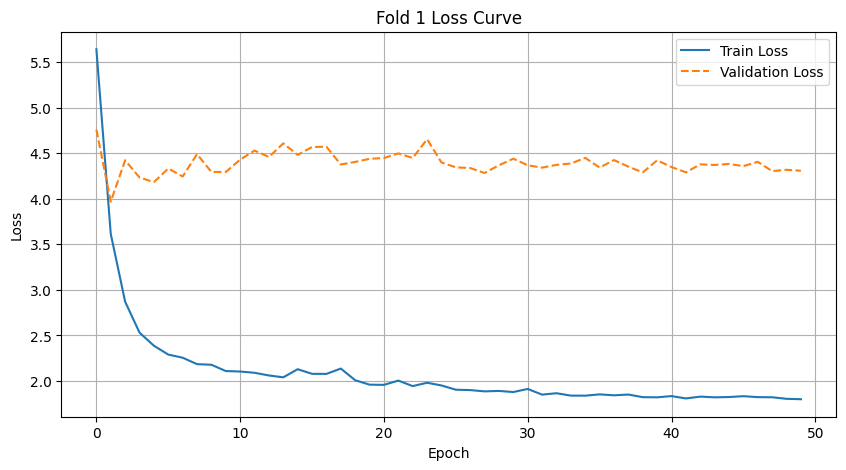


=== Training Fold 2/4 ===
Epoch 005 | Train=2.9185 | Val=2.9299 | RMSE=1.5095 | MAE=1.0031 | L_data=2.2679 L_phys=2.1170 L_night=0.1342
Epoch 010 | Train=2.1821 | Val=2.9741 | RMSE=1.5194 | MAE=0.9969 | L_data=2.2983 L_phys=2.1544 L_night=0.1471
Epoch 015 | Train=2.0097 | Val=2.8569 | RMSE=1.4972 | MAE=0.9258 | L_data=2.2305 L_phys=2.0246 L_night=0.0950
Epoch 020 | Train=1.9634 | Val=2.7634 | RMSE=1.4698 | MAE=0.8871 | L_data=2.1497 L_phys=1.9811 L_night=0.0966
Epoch 025 | Train=1.8575 | Val=2.9221 | RMSE=1.5241 | MAE=0.9339 | L_data=2.3113 L_phys=1.9792 L_night=0.0854
Epoch 030 | Train=1.8564 | Val=2.8946 | RMSE=1.5118 | MAE=0.9297 | L_data=2.2763 L_phys=1.9882 L_night=0.1094
Epoch 035 | Train=1.7961 | Val=2.9008 | RMSE=1.5210 | MAE=0.9294 | L_data=2.3015 L_phys=1.9582 L_night=0.0589
Epoch 040 | Train=1.7314 | Val=2.7536 | RMSE=1.4697 | MAE=0.8961 | L_data=2.1497 L_phys=1.9883 L_night=0.0371
Epoch 045 | Train=1.7874 | Val=2.7829 | RMSE=1.4745 | MAE=0.8854 | L_data=2.1667 L_phys=1.992

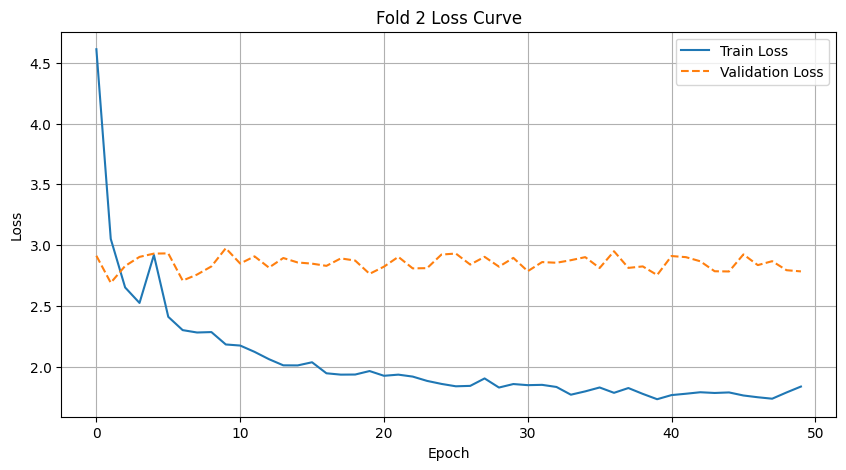


=== Training Fold 3/4 ===
Epoch 005 | Train=2.2363 | Val=4.0833 | RMSE=1.8229 | MAE=1.1443 | L_data=3.3292 L_phys=2.4431 L_night=0.1058
Epoch 010 | Train=1.9705 | Val=3.9407 | RMSE=1.7640 | MAE=1.1162 | L_data=3.1019 L_phys=2.7241 L_night=0.1077
Epoch 015 | Train=1.8356 | Val=3.7011 | RMSE=1.7120 | MAE=1.0483 | L_data=2.9273 L_phys=2.5330 L_night=0.0693
Epoch 020 | Train=1.7636 | Val=3.8678 | RMSE=1.7631 | MAE=1.0819 | L_data=3.1061 L_phys=2.4968 L_night=0.0635
Epoch 025 | Train=1.7313 | Val=3.8126 | RMSE=1.7432 | MAE=1.0454 | L_data=3.0486 L_phys=2.5003 L_night=0.0697
Epoch 030 | Train=1.6524 | Val=3.8826 | RMSE=1.7535 | MAE=1.0394 | L_data=3.0747 L_phys=2.6144 L_night=0.1178
Epoch 035 | Train=1.6115 | Val=3.8545 | RMSE=1.7558 | MAE=1.0334 | L_data=3.0938 L_phys=2.4964 L_night=0.0588
Epoch 040 | Train=1.5912 | Val=3.7899 | RMSE=1.7456 | MAE=1.0191 | L_data=3.0489 L_phys=2.4327 L_night=0.0560
Epoch 045 | Train=1.5422 | Val=3.9151 | RMSE=1.7768 | MAE=1.0275 | L_data=3.1589 L_phys=2.470

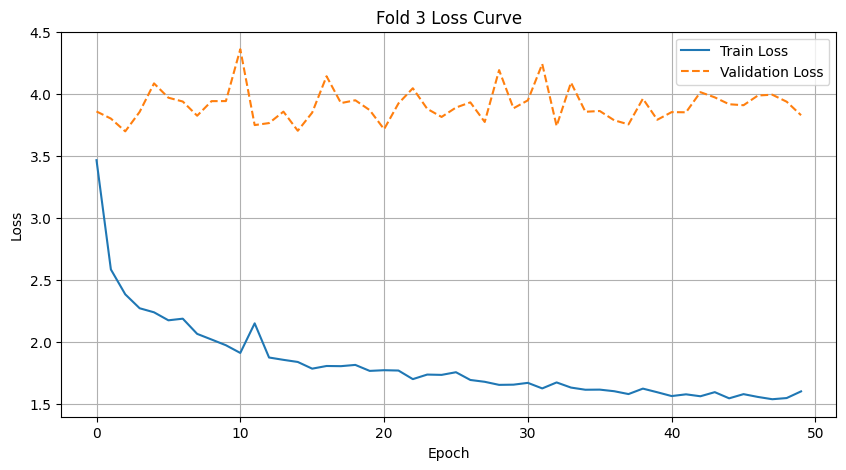


=== Training Fold 4/4 ===
Epoch 005 | Train=2.4406 | Val=5.5513 | RMSE=2.1355 | MAE=1.4757 | L_data=4.5724 L_phys=3.2120 L_night=0.0765
Epoch 010 | Train=2.0960 | Val=5.4167 | RMSE=2.0933 | MAE=1.3620 | L_data=4.3946 L_phys=3.3252 L_night=0.1227
Epoch 015 | Train=1.9579 | Val=5.5471 | RMSE=2.1382 | MAE=1.4012 | L_data=4.5821 L_phys=3.1695 L_night=0.0709
Epoch 020 | Train=1.8725 | Val=5.5358 | RMSE=2.1340 | MAE=1.3487 | L_data=4.5611 L_phys=3.1959 L_night=0.0798
Epoch 025 | Train=1.8205 | Val=5.4124 | RMSE=2.1031 | MAE=1.3883 | L_data=4.4295 L_phys=3.2380 L_night=0.0574
Epoch 030 | Train=1.7951 | Val=5.3471 | RMSE=2.0999 | MAE=1.3578 | L_data=4.4124 L_phys=3.0780 L_night=0.0565
Epoch 035 | Train=1.7791 | Val=5.9521 | RMSE=2.2296 | MAE=1.5251 | L_data=4.9713 L_phys=3.2011 L_night=0.1024
Epoch 040 | Train=1.7046 | Val=5.3993 | RMSE=2.0959 | MAE=1.3268 | L_data=4.3978 L_phys=3.2520 L_night=0.1299
Epoch 045 | Train=1.6978 | Val=5.3392 | RMSE=2.0956 | MAE=1.3240 | L_data=4.3903 L_phys=3.129

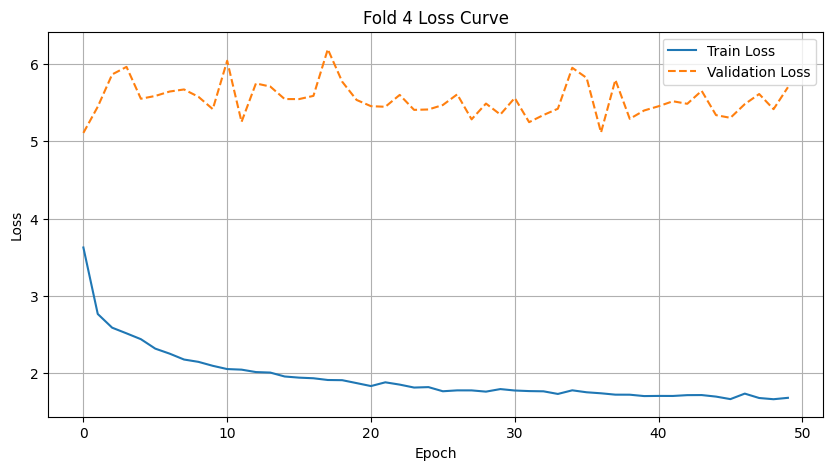


=== Final Cross-Validation Results ===
Average RMSE: 1.8157


In [36]:


results01, history01 = run_rolling_cv(df, configs)

